<a href="https://colab.research.google.com/github/esther033/2026-1_CV/blob/main/hw3/03_experiment_C_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 실험 C — 최적화 알고리즘 비교: SGD vs SGD+Momentum vs Adam

## 실험 목표
- 세 옵티마이저의 학습 곡선과 수렴 특성 비교
- 학습률 변화(0.1, 0.01, 0.001)에 따른 영향 분석
- **Exponential Decay** 적용 효과 확인

## 실험 조건
| 항목 | 값 |
|---|---|
| 데이터셋 | Fashion-MNIST |
| 네트워크 | MLP: `784 → 256 → 128 → 10`, ReLU |
| 손실함수 | CrossEntropy |
| Epoch | 30 |
| Batch size | 128 |
| 옵티마이저 | SGD / SGD+Momentum(0.9) / Adam |
| 학습률 | 0.1, 0.01, 0.001 (각 옵티마이저별) |
| 시드 | 42 |

## 학습률 가이드 (과제 명시)
| Optimizer | 추천 lr |
|---|---|
| SGD | 0.01 ~ 0.1 |
| SGD + Momentum | 0.01 ~ 0.05 |
| Adam | 0.001 ~ 0.01 |


## 0. 셋업

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/Colab Notebooks/CV_hw#3')

from common_utils import (
    set_seed, get_device, fit,
    plot_loss_acc_curves, plot_gradient_flow, summarize_histories
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

set_seed(42)
device = get_device()
print("Device:", device)


Mounted at /content/drive
Device: cuda


## 1. 데이터셋: Fashion-MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))
])

train_set = datasets.FashionMNIST('./data', train=True,  download=True, transform=transform)
test_set  = datasets.FashionMNIST('./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)
print(f"Train: {len(train_set)}, Test: {len(test_set)}")


100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.81MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]

Train: 60000, Test: 10000


## 2. 모델 정의

In [3]:
def make_mlp_c():
    """실험 C 공통 MLP. 784 → 256 → 128 → 10."""
    return nn.Sequential(
        nn.Linear(784, 256),
        nn.ReLU(),
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Linear(128, 10),
    )


## 3. 9개 조합 학습 (3 optimizer × 3 lr)

In [4]:
EPOCHS_C = 30

OPTIMIZERS = {
    'SGD':          lambda params, lr: torch.optim.SGD(params, lr=lr),
    'SGD+Momentum': lambda params, lr: torch.optim.SGD(params, lr=lr, momentum=0.9),
    'Adam':         lambda params, lr: torch.optim.Adam(params, lr=lr),
}
LR_LIST = [0.1, 0.01, 0.001]

histories_c = {}     # key: 'OptName_lrX'
models_c = {}

for opt_name, opt_fn in OPTIMIZERS.items():
    for lr in LR_LIST:
        key = f"{opt_name}_lr{lr}"
        print(f"\n>>> {key}")
        set_seed(42)
        model = make_mlp_c().to(device)
        opt = opt_fn(model.parameters(), lr)
        histories_c[key] = fit(
            model, train_loader, test_loader,
            nn.CrossEntropyLoss(), opt, device,
            epochs=EPOCHS_C, log_every=10
        )
        models_c[key] = model



>>> SGD_lr0.1
[  1/30] train_loss=0.8267 train_acc=70.84% test_loss=0.5588 test_acc=80.14% grad_norm=1.3058 lr=0.10000
[ 10/30] train_loss=0.3032 train_acc=88.86% test_loss=0.3427 test_acc=87.48% grad_norm=1.0679 lr=0.10000
[ 20/30] train_loss=0.2348 train_acc=91.22% test_loss=0.3219 test_acc=88.82% grad_norm=1.1125 lr=0.10000
[ 30/30] train_loss=0.1913 train_acc=92.88% test_loss=0.3391 test_acc=88.77% grad_norm=1.1623 lr=0.10000

>>> SGD_lr0.01
[  1/30] train_loss=1.8523 train_acc=44.58% test_loss=1.2313 test_acc=60.66% grad_norm=0.6429 lr=0.01000
[ 10/30] train_loss=0.4861 train_acc=83.08% test_loss=0.5050 test_acc=82.25% grad_norm=1.5285 lr=0.01000
[ 20/30] train_loss=0.4179 train_acc=85.51% test_loss=0.4484 test_acc=84.15% grad_norm=1.6539 lr=0.01000
[ 30/30] train_loss=0.3816 train_acc=86.77% test_loss=0.4312 test_acc=84.75% grad_norm=1.6465 lr=0.01000

>>> SGD_lr0.001
[  1/30] train_loss=2.2853 train_acc=19.08% test_loss=2.2664 test_acc=27.79% grad_norm=0.3646 lr=0.00100
[ 10/30

## 4. 시각화: Optimizer별 학습률 변화 비교

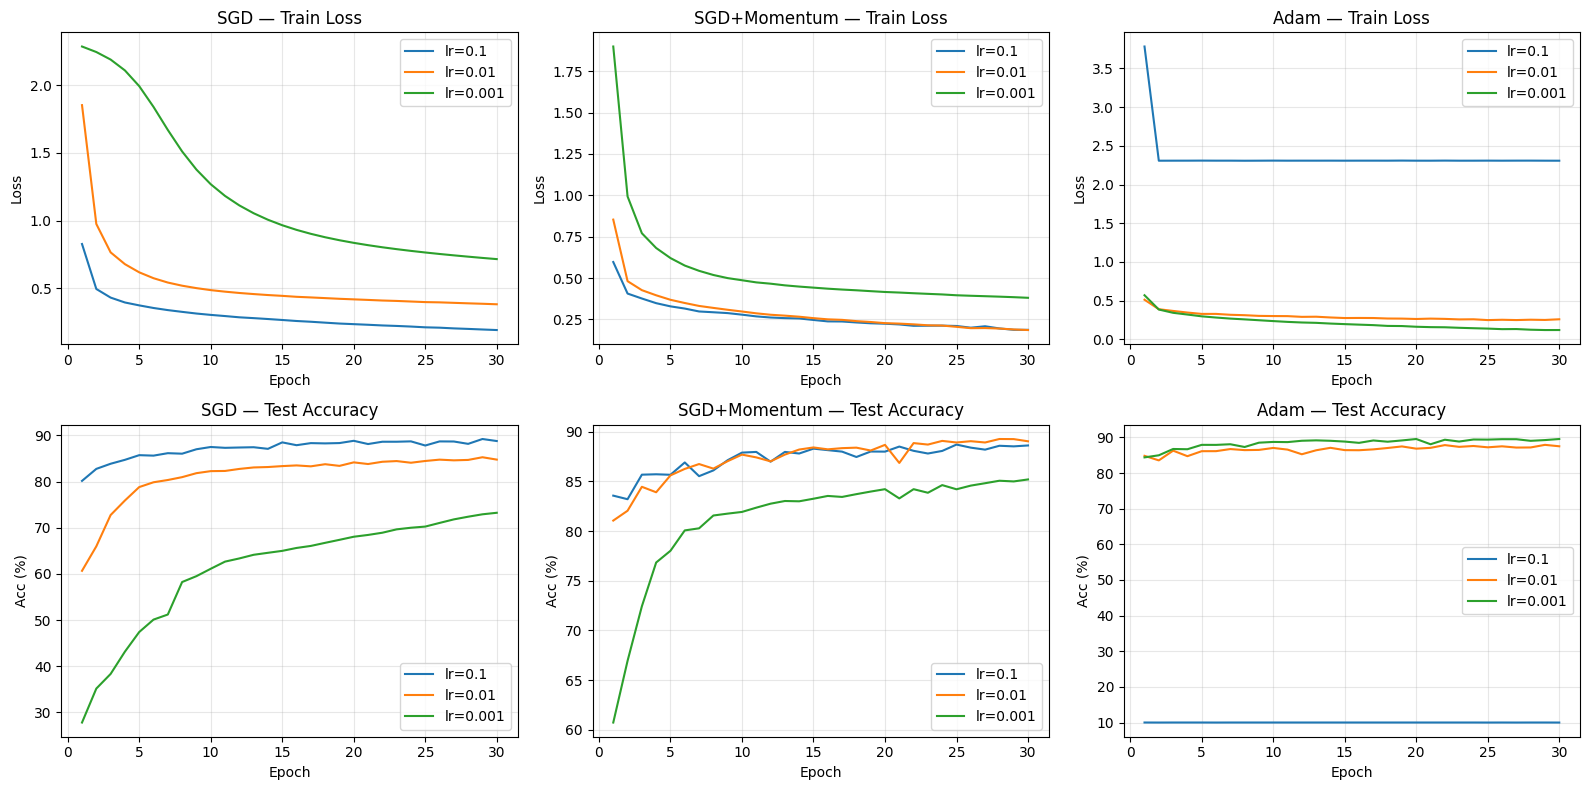

In [5]:
# 3x3 subplot으로 시각화
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for col, opt_name in enumerate(OPTIMIZERS.keys()):
    ax_loss = axes[0, col]
    ax_acc  = axes[1, col]
    for lr in LR_LIST:
        key = f"{opt_name}_lr{lr}"
        h = histories_c[key]
        epochs = range(1, len(h['train_loss']) + 1)
        ax_loss.plot(epochs, h['train_loss'], label=f"lr={lr}")
        ax_acc.plot(epochs, h['test_acc'],   label=f"lr={lr}")
    ax_loss.set_title(f"{opt_name} — Train Loss")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(); ax_loss.grid(alpha=0.3)
    ax_acc.set_title(f"{opt_name} — Test Accuracy")
    ax_acc.set_xlabel("Epoch"); ax_acc.set_ylabel("Acc (%)")
    ax_acc.legend(); ax_acc.grid(alpha=0.3)

plt.tight_layout(); plt.show()


**관찰 가이드**
- SGD lr=0.1: 큰 학습률로 빠르게 학습되지만 진동 발생 가능.
- SGD lr=0.001: 너무 느려 정체.
- Adam lr=0.1: overshooting으로 학습 실패하거나 매우 불안정.
- Adam lr=0.001: 가장 안정적으로 빠른 수렴.
- SGD+Momentum은 동일 lr에서 SGD 단독보다 빠르게 수렴 (momentum 누적 효과).


## 5. 정량 비교표

In [6]:
# 각 조합의 final acc, best acc, min loss, convergence epoch, gradient 안정성
rows = []
for key, h in histories_c.items():
    opt_name, lr_str = key.rsplit('_', 1)
    lr_val = float(lr_str.replace('lr', ''))
    # gradient norm의 표준편차 (안정성 지표: 작을수록 안정)
    grad_std = np.std(h['grad_norm'])
    min_loss = min(h['train_loss'])
    conv_ep  = next(
        (i + 1 for i, v in enumerate(h['train_loss']) if v <= min_loss * 1.05),
        len(h['train_loss'])
    )
    rows.append({
        'optimizer': opt_name,
        'lr': lr_val,
        'final_test_acc(%)': round(h['test_acc'][-1], 2),
        'best_test_acc(%)':  round(max(h['test_acc']), 2),
        'min_train_loss':    round(min_loss, 4),
        'convergence_epoch': conv_ep,
        'grad_norm_std':     round(grad_std, 4),
    })

results_c = pd.DataFrame(rows).sort_values(['optimizer', 'lr'])
results_c.to_csv('results_C_optimizer.csv', index=False)
results_c


,optimizer,lr,final_test_acc(%),best_test_acc(%),min_train_loss,convergence_epoch,grad_norm_std
8,Adam,0.001,89.57,89.57,0.1206,28,0.2097
7,Adam,0.010,87.53,87.93,0.2493,23,0.0912
6,Adam,0.100,9.99,10.00,2.3079,2,0.7213
2,SGD,0.001,73.23,73.23,0.7152,27,0.2111
1,SGD,0.010,84.75,85.26,0.3816,25,0.2462
0,SGD,0.100,88.77,89.21,0.1913,28,0.0524
5,SGD+Momentum,0.001,85.19,85.19,0.3805,25,0.2519
4,SGD+Momentum,0.010,89.03,89.26,0.1855,28,0.0597
3,SGD+Momentum,0.100,88.61,88.70,0.1868,28,0.0827


## 6. 각 옵티마이저의 최적 lr끼리 비교

Best lr per optimizer: ['SGD_lr0.1', 'SGD+Momentum_lr0.01', 'Adam_lr0.001']


/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:274: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:274: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


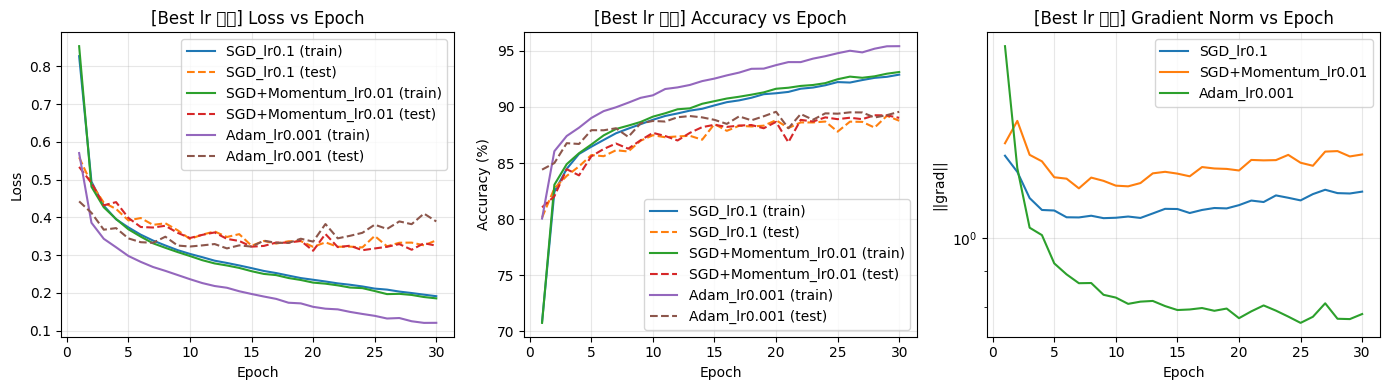

In [7]:
# 각 optimizer에서 best_test_acc 기준으로 최고 lr 선택
best_keys = []
for opt_name in OPTIMIZERS.keys():
    subset = {k: v for k, v in histories_c.items() if k.startswith(opt_name + '_')}
    best_key = max(subset, key=lambda k: max(subset[k]['test_acc']))
    best_keys.append(best_key)
print("Best lr per optimizer:", best_keys)

best_histories = {k: histories_c[k] for k in best_keys}
plot_loss_acc_curves(best_histories, title_prefix='[Best lr 비교]')


## 7. Exponential Decay 추가 실험

각 옵티마이저의 최적 lr에 `ExponentialLR(gamma=0.9)`를 적용해본다.



>>> SGD_lr0.1_decay
[  1/30] train_loss=0.8267 train_acc=70.84% test_loss=0.5588 test_acc=80.14% grad_norm=1.3058 lr=0.10000
[ 10/30] train_loss=0.3130 train_acc=88.58% test_loss=0.3568 test_acc=87.27% grad_norm=1.0865 lr=0.03874
[ 20/30] train_loss=0.2686 train_acc=90.21% test_loss=0.3346 test_acc=88.23% grad_norm=1.1511 lr=0.01351
[ 30/30] train_loss=0.2536 train_acc=90.76% test_loss=0.3321 test_acc=88.11% grad_norm=1.1793 lr=0.00471

>>> SGD+Momentum_lr0.01_decay
[  1/30] train_loss=0.8532 train_acc=70.75% test_loss=0.5336 test_acc=81.05% grad_norm=1.3597 lr=0.01000
[ 10/30] train_loss=0.3146 train_acc=88.62% test_loss=0.3604 test_acc=87.21% grad_norm=1.2308 lr=0.00387
[ 20/30] train_loss=0.2685 train_acc=90.31% test_loss=0.3366 test_acc=88.07% grad_norm=1.2827 lr=0.00135
[ 30/30] train_loss=0.2527 train_acc=90.99% test_loss=0.3295 test_acc=88.48% grad_norm=1.3182 lr=0.00047

>>> Adam_lr0.001_decay
[  1/30] train_loss=0.5703 train_acc=80.05% test_loss=0.4423 test_acc=84.41% grad_no

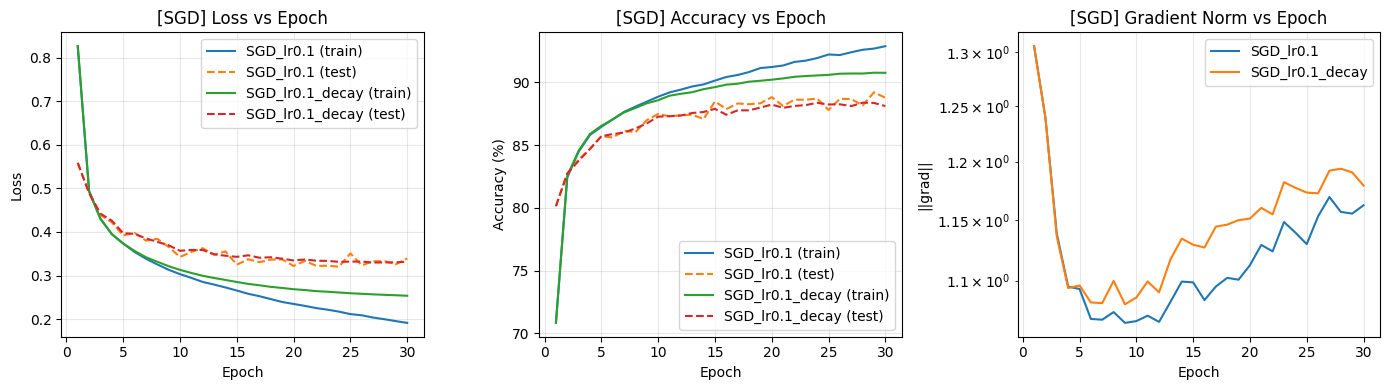

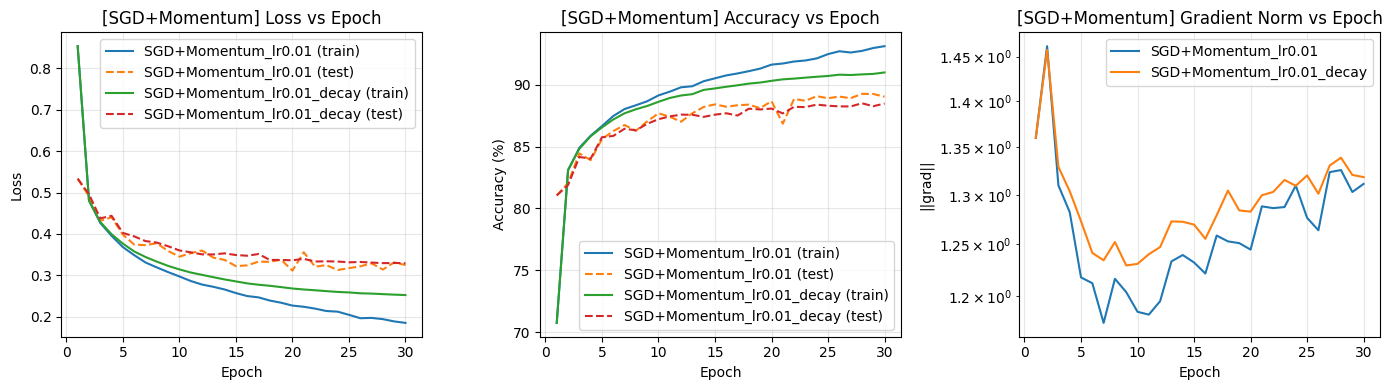

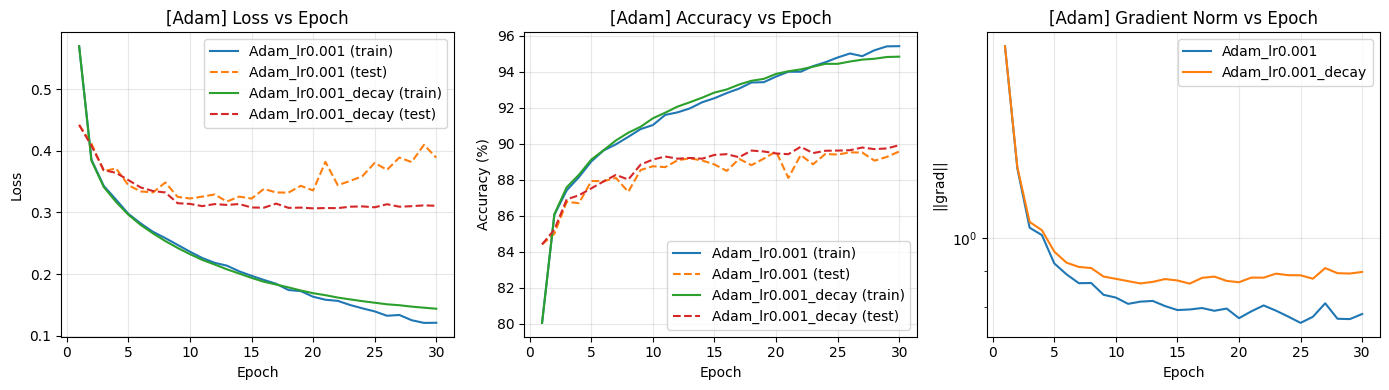

In [10]:
histories_decay = {}

for key in best_keys:
    opt_name, lr_str = key.rsplit('_', 1)
    lr_val = float(lr_str.replace('lr', ''))

    set_seed(42)
    model = make_mlp_c().to(device)
    opt = OPTIMIZERS[opt_name](model.parameters(), lr_val)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(opt, gamma=0.9)
    new_key = f"{opt_name}_lr{lr_val}_decay"
    print(f"\n>>> {new_key}")
    histories_decay[new_key] = fit(
        model, train_loader, test_loader,
        nn.CrossEntropyLoss(), opt, device,
        epochs=EPOCHS_C, scheduler=scheduler, log_every=10
    )

# 최적 lr (decay 없음) vs (decay 있음) 비교
for orig_key, decay_key in zip(best_keys, histories_decay.keys()):
    cmp = {orig_key: histories_c[orig_key], decay_key: histories_decay[decay_key]}
    plot_loss_acc_curves(cmp, title_prefix=f'[{orig_key.rsplit("_",1)[0]}]')


## 8. Gradient Flow 비교 (옵티마이저별)

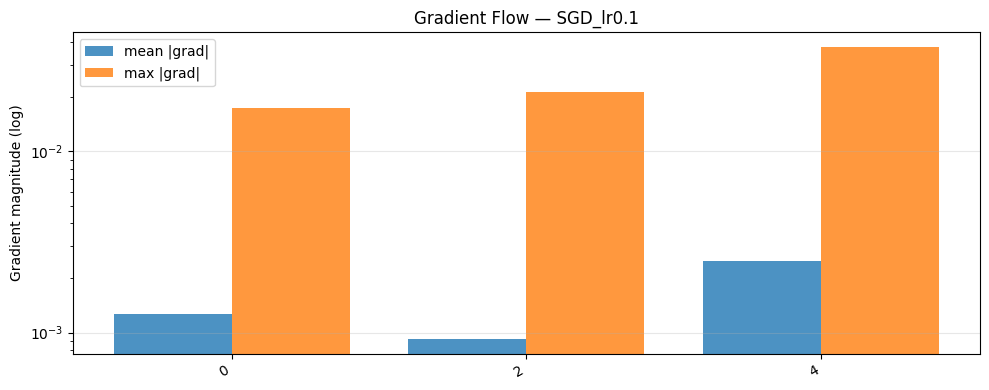

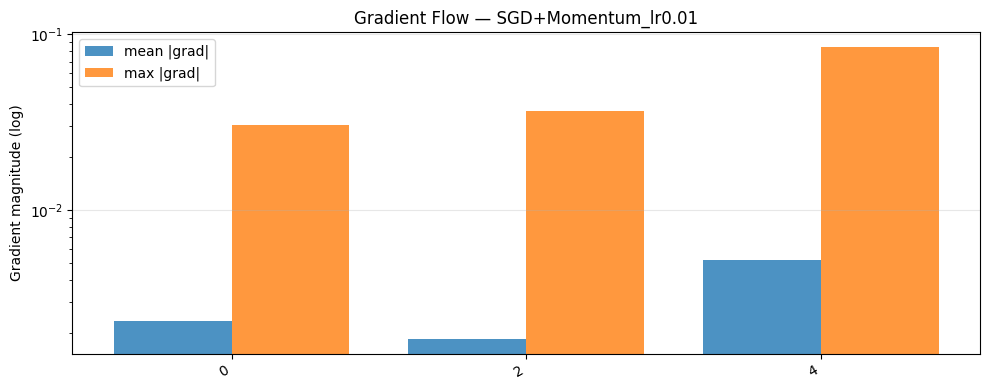

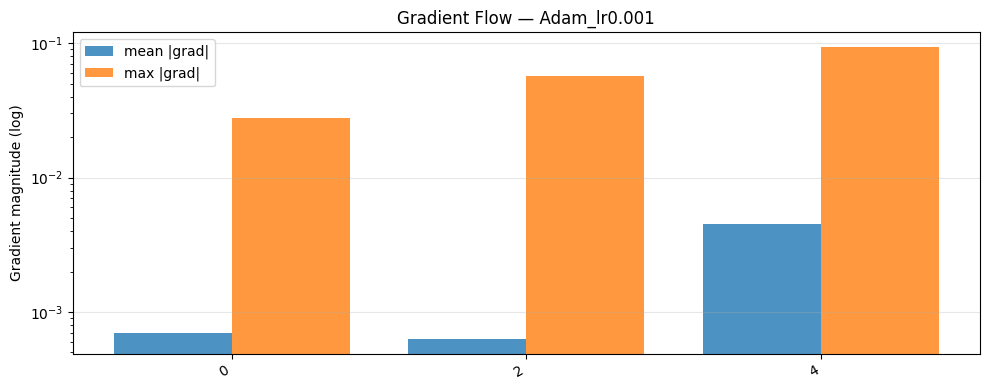

In [8]:
# 각 옵티마이저의 최적 모델에서 한 배치 backward → gradient flow
for key in best_keys:
    model = models_c[key]
    model.train()
    inputs, targets = next(iter(train_loader))
    inputs, targets = inputs.to(device), targets.to(device)
    loss = nn.CrossEntropyLoss()(model(inputs), targets)
    model.zero_grad()
    loss.backward()
    plot_gradient_flow(model, title=f'Gradient Flow — {key}')


## 9. 해결 검증 실험

너무 큰 학습률(예: SGD lr=0.1)이 실패한 경우, gradient clipping을 적용해서 안정화되는지 확인.


>>> SGD lr=0.1 + gradient clipping (max_norm=1.0)
[10/30] train_loss=0.3202 test_acc=86.82%
[20/30] train_loss=0.2469 test_acc=88.36%
[30/30] train_loss=0.2021 test_acc=88.40%


/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:274: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/content/drive/MyDrive/Colab Notebooks/CV_hw#3/common_utils.py:274: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


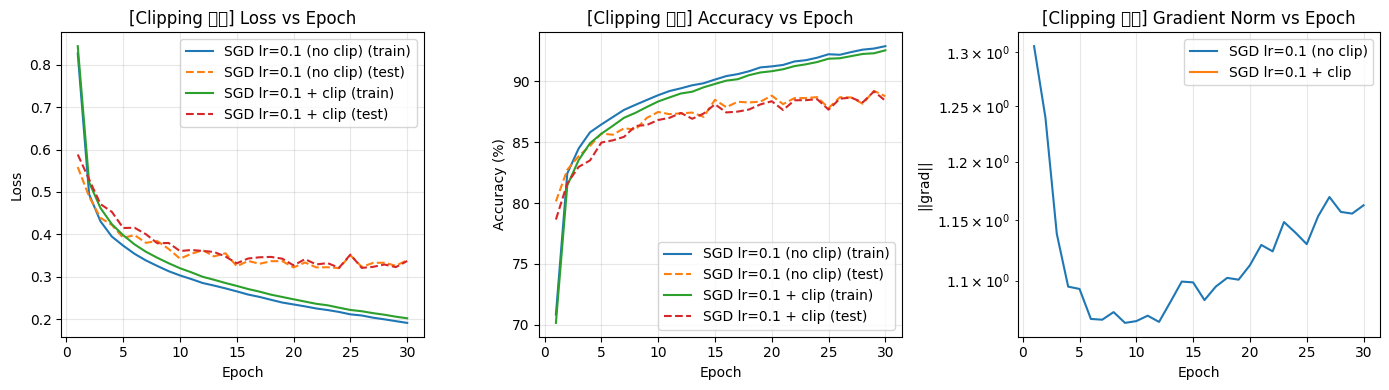

In [9]:
# Gradient clipping 적용 학습 루프
def fit_with_clipping(model, train_loader, test_loader, loss_fn, opt, device, epochs, max_norm=1.0):
    history = {'train_loss': [], 'train_acc': [], 'test_loss': [],
               'test_acc': [], 'grad_norm': [], 'lr': []}
    for epoch in range(1, epochs + 1):
        model.train()
        tl, c, t = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            logits = model(x)
            loss = loss_fn(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)  # 핵심
            opt.step()
            tl += loss.item() * x.size(0)
            c  += (logits.argmax(1) == y).sum().item()
            t  += x.size(0)
        from common_utils import evaluate
        te_loss, te_acc = evaluate(model, test_loader, loss_fn, device)
        history['train_loss'].append(tl/t); history['train_acc'].append(100*c/t)
        history['test_loss'].append(te_loss); history['test_acc'].append(te_acc)
        history['grad_norm'].append(0); history['lr'].append(opt.param_groups[0]['lr'])
        if epoch % 10 == 0:
            print(f"[{epoch}/{epochs}] train_loss={tl/t:.4f} test_acc={te_acc:.2f}%")
    return history

# SGD lr=0.1 + gradient clipping
set_seed(42)
model_clip = make_mlp_c().to(device)
opt_clip = torch.optim.SGD(model_clip.parameters(), lr=0.1)
print(">>> SGD lr=0.1 + gradient clipping (max_norm=1.0)")
hist_clip = fit_with_clipping(model_clip, train_loader, test_loader,
                              nn.CrossEntropyLoss(), opt_clip, device,
                              epochs=EPOCHS_C, max_norm=1.0)

plot_loss_acc_curves(
    {'SGD lr=0.1 (no clip)': histories_c['SGD_lr0.1'],
     'SGD lr=0.1 + clip':    hist_clip},
    title_prefix='[Clipping 효과]'
)
